In [1]:
#pip install gensim

In [2]:
import gensim
import os

In [5]:
# import nltk
from nltk import sent_tokenize
from gensim.utils import simple_preprocess

story=[]

for file in os.listdir("Data"):
    f=open(os.path.join("Data",file))
    corpus=f.read()
    raw_sent=sent_tokenize(corpus)
    for sent in raw_sent:
        story.append(simple_preprocess(sent))

In [6]:
# pip install nltk

In [8]:
print(len(story))

145020


In [10]:
model=gensim.models.Word2Vec(
    window=10,
    min_count=2
)

In [11]:
model.build_vocab(story)

In [14]:
model.train(story,total_examples=model.corpus_count, epochs=model.epochs)

(6569572, 8628190)

In [15]:
model.wv.most_similar("daenerys")

[('stormborn', 0.814732551574707),
 ('unburnt', 0.7409569025039673),
 ('princess', 0.7318702340126038),
 ('myrcella', 0.7105209231376648),
 ('targaryen', 0.7005053162574768),
 ('elia', 0.6841801404953003),
 ('queen', 0.6611849665641785),
 ('margaery', 0.6437183618545532),
 ('shireen', 0.6401353478431702),
 ('viserys', 0.6362618803977966)]

In [16]:
model.wv.doesnt_match(["jon","rikon","robb","arya","sansa","bran"])

'jon'

In [17]:
model.wv.doesnt_match(["cersei","jaime","bronn","tyrion"])

'bronn'

In [19]:
# model.wv["jon"]
model.wv["king"]

array([ 0.78362596,  0.8516422 ,  1.8614541 ,  2.9372184 , -0.8223617 ,
        1.9766197 , -0.2517292 ,  0.10236251, -2.1907527 ,  0.88886863,
        0.21128303, -0.38859126,  0.87223125,  2.5334306 , -2.4250646 ,
       -1.7689942 ,  0.17913847,  3.041176  ,  0.9086054 , -0.5645768 ,
        3.0603273 , -0.9323096 ,  4.072739  , -2.8968124 , -1.6556286 ,
        1.7608162 , -0.7030481 , -0.35049006, -0.6138624 ,  1.1711177 ,
       -2.2444522 ,  0.32602227, -0.49654984, -0.24389586,  0.9161197 ,
       -2.6725621 , -1.5715325 , -0.29963475,  0.9850032 , -2.7305996 ,
        0.67768914,  1.6066127 ,  3.113702  ,  0.08688204, -1.9637713 ,
       -0.9366851 , -1.1747437 , -3.4236364 ,  2.5503364 , -5.444932  ,
       -3.0163655 , -1.8774298 , -1.2570038 , -2.361059  ,  2.5252864 ,
       -2.7153285 ,  0.6349603 ,  1.6934885 , -0.33096045,  1.858379  ,
        1.5216407 ,  1.1460515 ,  0.79447144,  1.5391526 , -0.30856976,
        2.6643977 , -0.90925455, -0.4008967 , -0.50132734, -2.04

In [20]:
model.wv.similarity('cersei',"sansa")

np.float32(0.7243041)

In [21]:
model.wv.similarity("tywin","sansa")

np.float32(0.2478144)

In [22]:
model.wv.similarity("arya","sansa")

np.float32(0.84113836)

In [24]:
model.wv.get_normed_vectors().shape

(17453, 100)

In [25]:
y=model.wv.index_to_key

In [26]:
y

['the',
 'and',
 'to',
 'of',
 'he',
 'his',
 'was',
 'you',
 'her',
 'in',
 'it',
 'had',
 'that',
 'she',
 'as',
 'with',
 'him',
 'not',
 'but',
 'for',
 'they',
 'is',
 'at',
 'on',
 'said',
 'my',
 'have',
 'be',
 'lord',
 'them',
 'no',
 'from',
 'would',
 'were',
 'me',
 'your',
 'one',
 'all',
 'when',
 'will',
 'ser',
 'if',
 'so',
 'their',
 'we',
 'could',
 'are',
 'man',
 'there',
 'this',
 'up',
 'been',
 'what',
 'did',
 'by',
 'king',
 'do',
 'men',
 'back',
 'out',
 'more',
 'or',
 'who',
 'down',
 'well',
 'than',
 'only',
 'like',
 'jon',
 'some',
 'father',
 'old',
 'hand',
 'even',
 'too',
 'tyrion',
 'before',
 'never',
 'an',
 'off',
 'know',
 'see',
 'into',
 'made',
 'now',
 'eyes',
 'black',
 'told',
 'lady',
 'thought',
 'time',
 'then',
 'how',
 'long',
 'has',
 'can',
 'might',
 'us',
 'come',
 'where',
 'here',
 'through',
 'face',
 'still',
 'head',
 'red',
 'll',
 'way',
 'boy',
 'page',
 'must',
 'once',
 'queen',
 'good',
 'two',
 'brother',
 'night',
 

In [27]:
from sklearn.decomposition import PCA

In [28]:
pca=PCA(n_components=3)

In [30]:
x=pca.fit_transform(model.wv.get_normed_vectors())

In [31]:
x[:5]

array([[ 0.17267495,  0.59204584, -0.04554209],
       [ 0.16447794,  0.3503318 ,  0.01905166],
       [-0.29032278,  0.56240654,  0.2466571 ],
       [-0.00205525,  0.34567645, -0.12106672],
       [-0.090131  ,  0.5491102 ,  0.2846706 ]], dtype=float32)

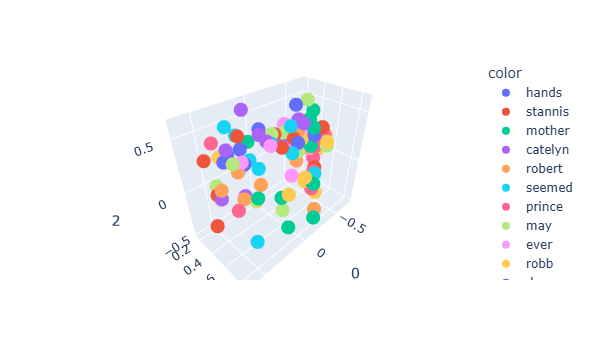

In [35]:
import plotly.express as px
fig=px.scatter_3d(x[200:300],x=0,y=1,z=2,color=y[200:300])
fig.show()